Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')
Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered'],
      dtype='object')

Training Gradient Boosting Regressor...
Validation RMSLE: 0.282390
MAE: 21.72
RMSE: 35.39
R² Score: 0.9512

--- Peak Demand Analysis (Gradient Boosting) ---
Top 10 Actual Peak Demands: [775 785 801 812 822 830 850 857 872 956]
Top 10 Predicted Peak Demands: [782 786 786 788 802 804 808 808 810 857]
Peak Demand MAE: 34.48


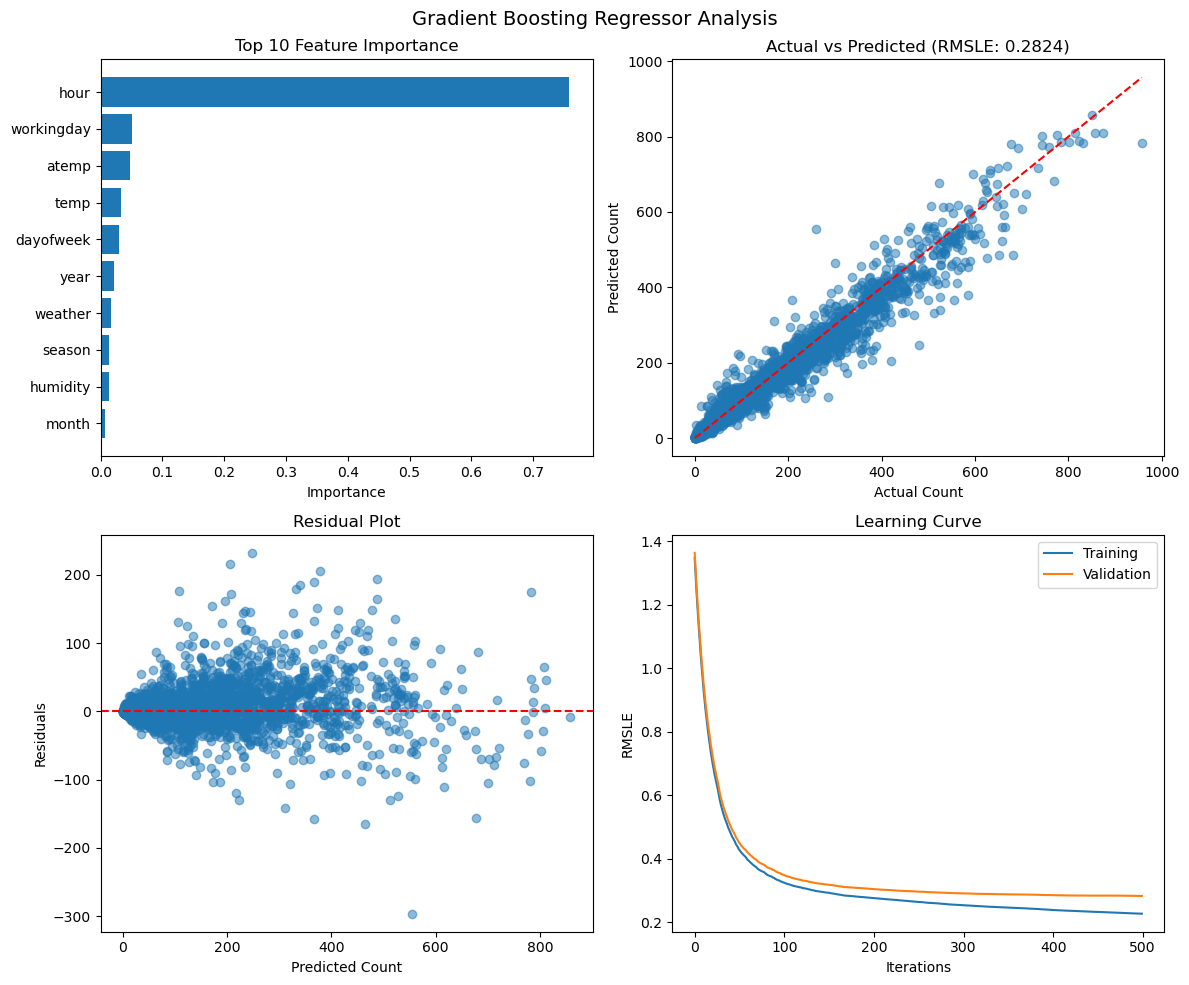


Training Random Forest Regressor...
Validation RMSLE: 0.439985
MAE: 40.77
RMSE: 69.20
R² Score: 0.8134
Peak Demand MAE: 233.13


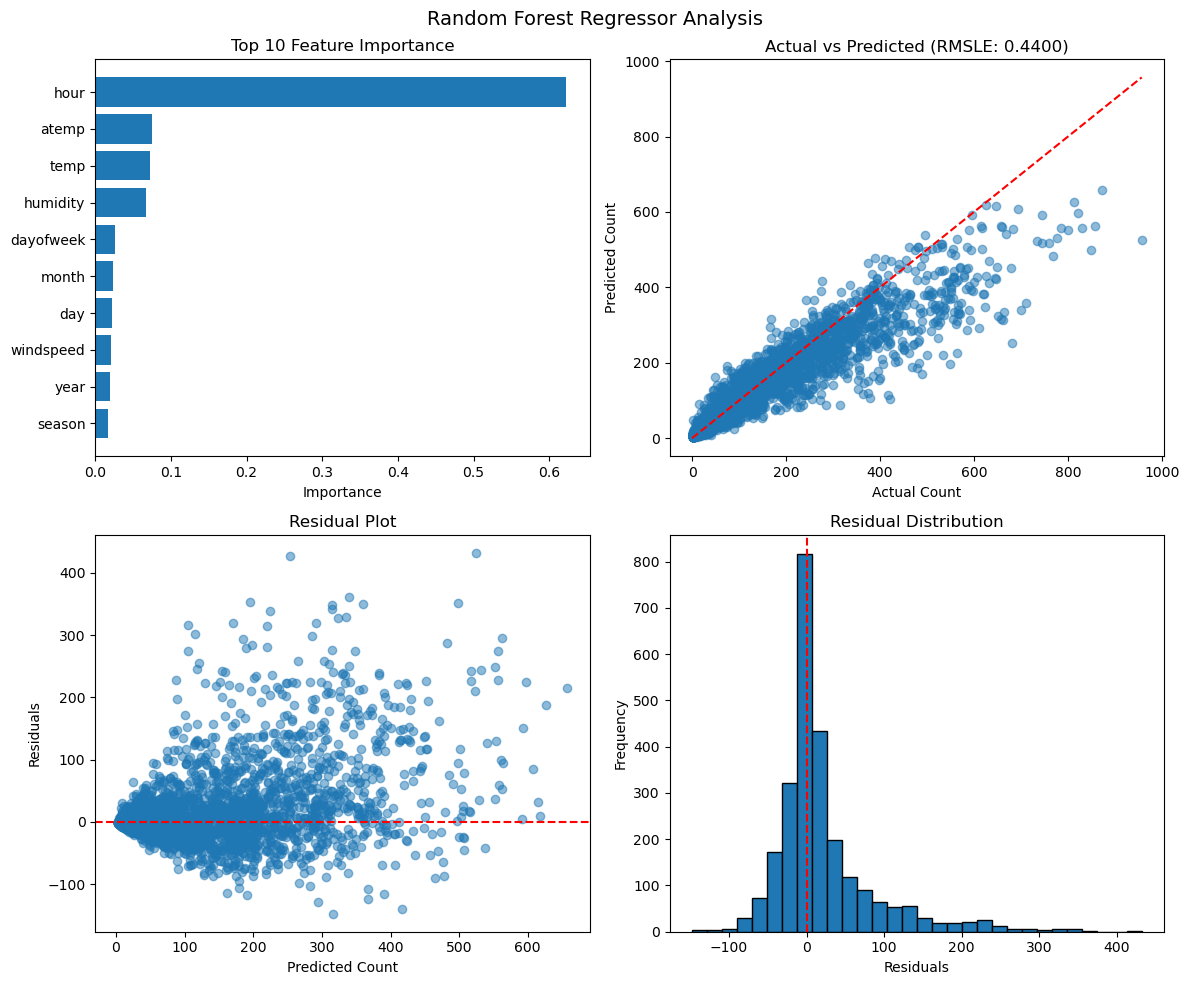


Training XGBoost Regressor...
Validation RMSLE: 0.277318
MAE: 20.07
RMSE: 32.64
R² Score: 0.9585
Peak Demand MAE: 14.88


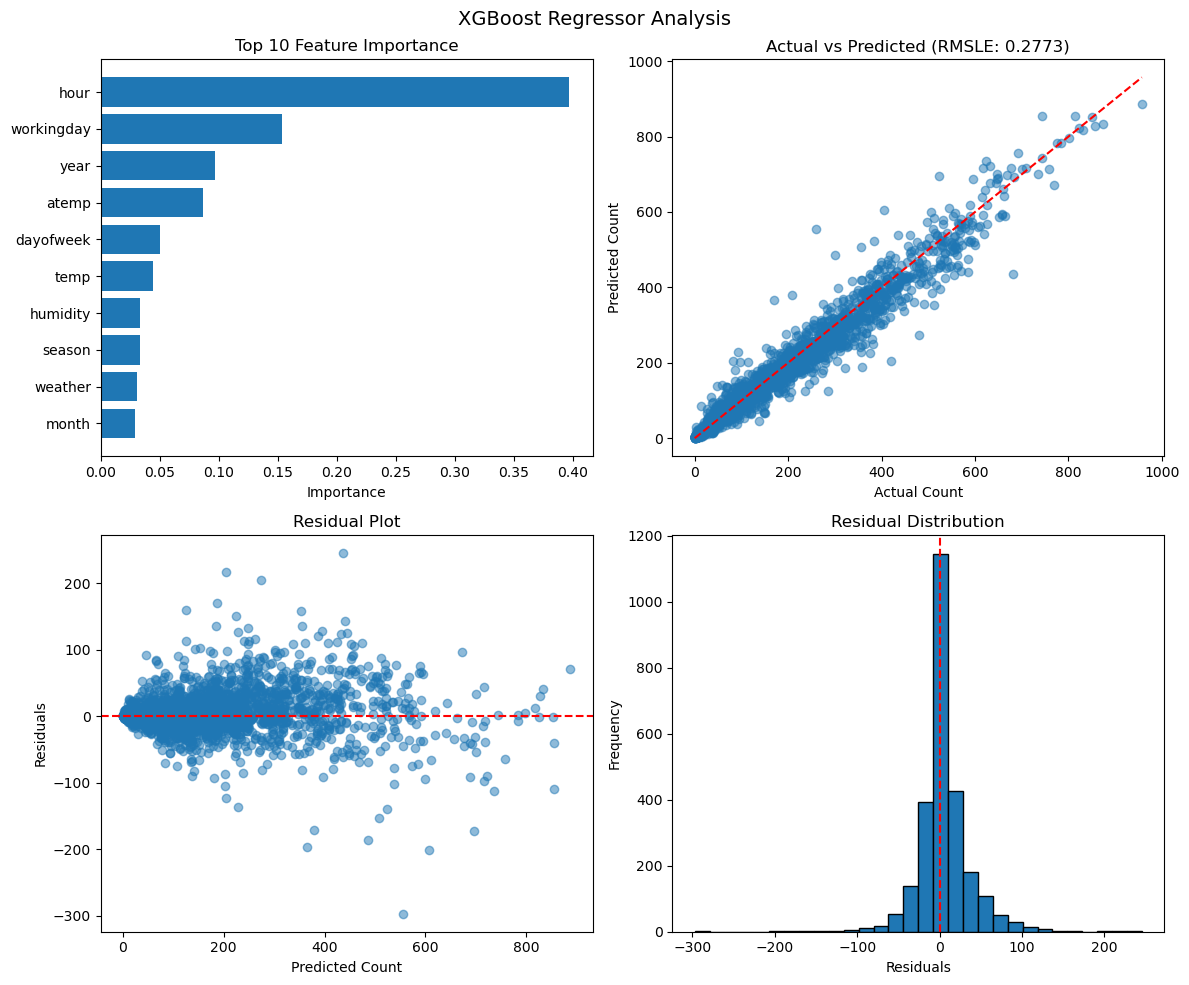


Training CatBoost Regressor...
Validation RMSLE: 0.282540
MAE: 22.09
RMSE: 36.04
R² Score: 0.9494
Peak Demand MAE: 50.02


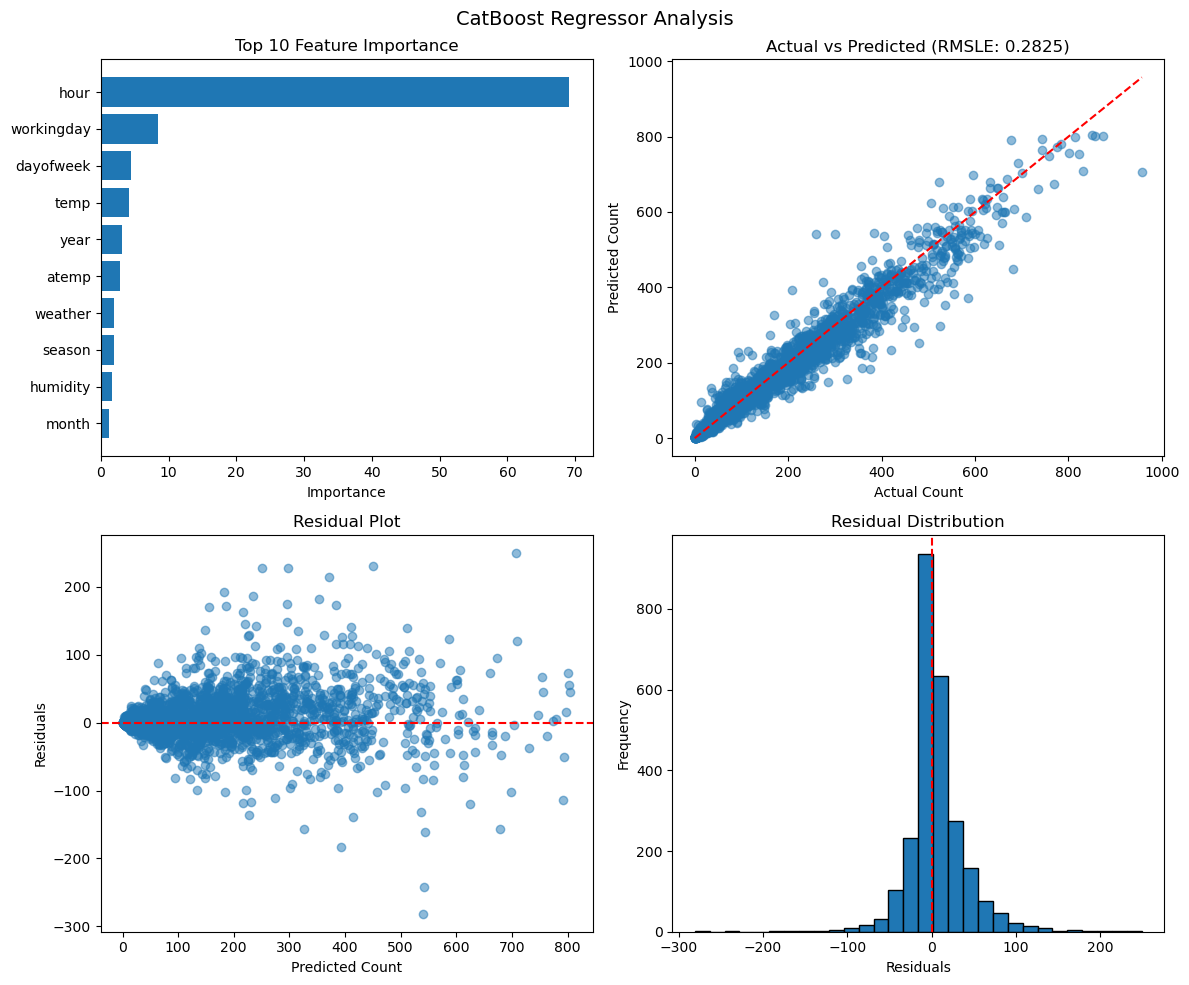

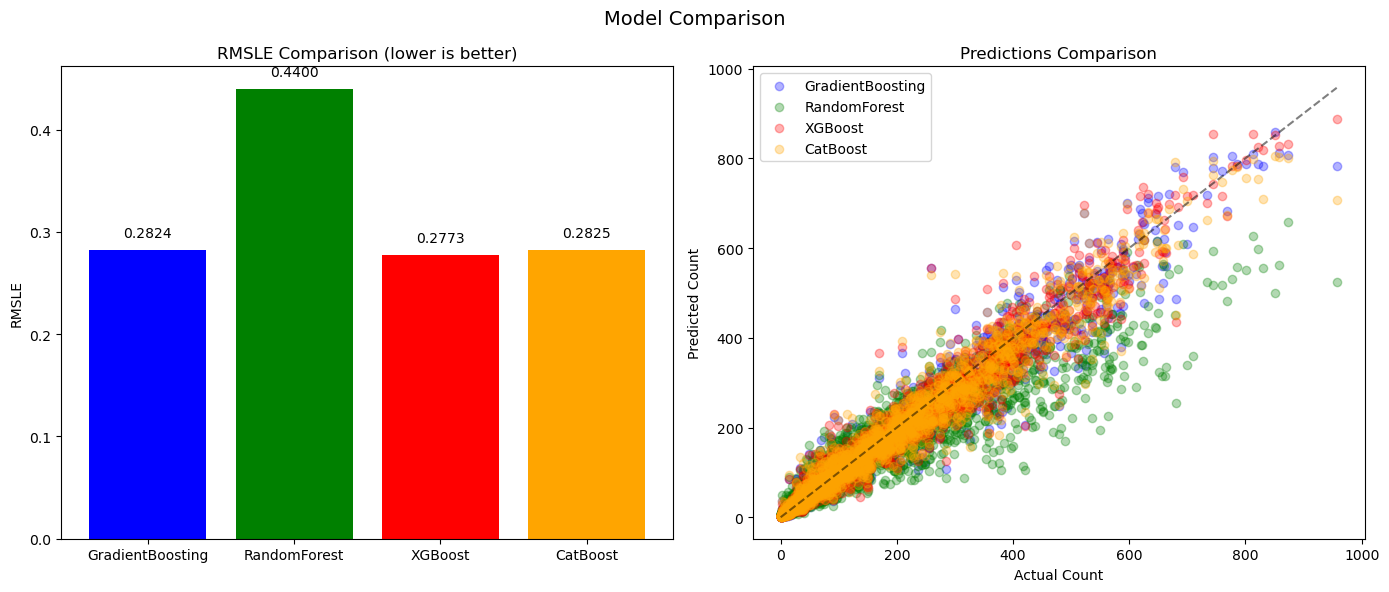


COMPREHENSIVE MODEL EVALUATION METRICS
Model              RMSLE      MAE        RMSE       R² Score     Peak MAE    
----------------------------------------------------------------------
GradientBoosting   0.2824     21.72     35.39     0.9512       34.48
RandomForest       0.4400     40.77     69.20     0.8134       233.13
XGBoost            0.2773     20.07     32.64     0.9585       14.88
CatBoost           0.2825     22.09     36.04     0.9494       50.02

BEST MODEL PER METRIC
Best RMSLE: XGBoost (0.2773)
Best MAE: XGBoost (20.07)
Best RMSE: XGBoost (32.64)
Best R² Score: XGBoost (0.9585)
Best Peak Demand MAE: XGBoost (14.88)

Validation RMSLE Scores Summary
GradientBoosting    : 0.282390
RandomForest        : 0.439985
XGBoost             : 0.277318
CatBoost            : 0.282540

Best Model (by RMSLE): XGBoost with RMSLE: 0.277318

Retraining XGBoost on full dataset...

Saving models...
✓ bike_model_gradientboosting.pkl saved
✓ bike_model_randomforest.pkl saved
✓ bike_model_xgb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import catboost as cb
import pickle

# Load data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.columns)
print(test.columns)

# Convert datetime
train['datetime'] = pd.to_datetime(train['datetime'], errors='coerce')
test['datetime'] = pd.to_datetime(test['datetime'], errors='coerce')

# Extract features
for df in [train, test]:
    df['hour'] = df['datetime'].dt.hour
    df['day'] = df['datetime'].dt.day
    df['month'] = df['datetime'].dt.month
    df['year'] = df['datetime'].dt.year
    df['dayofweek'] = df['datetime'].dt.dayofweek

# Drop columns that leak target information
train = train.drop(['datetime', 'casual', 'registered'], axis=1)

# Save datetime for submission
test_datetime = test['datetime']
test = test.drop(['datetime'], axis=1)

# Prepare target and features
y = np.log1p(train['count'])
X = train.drop('count', axis=1)

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Dictionary to store models and their validation scores
models = {}
validation_scores = {}

# Store additional metrics
metrics_summary = {}

# 1. Gradient Boosting (Original)
print("\n" + "="*50)
print("Training Gradient Boosting Regressor...")
print("="*50)

gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)
val_pred_gb = gb_model.predict(X_val)
rmsle_gb = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(val_pred_gb)))
print(f"Validation RMSLE: {rmsle_gb:.6f}")

# Calculate additional metrics for Gradient Boosting
mae_gb = mean_absolute_error(np.expm1(y_val), np.expm1(val_pred_gb))
rmse_gb = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred_gb)))
r2_gb = r2_score(np.expm1(y_val), np.expm1(val_pred_gb))

print(f"MAE: {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")
print(f"R² Score: {r2_gb:.4f}")

# Peak Demand Analysis for Gradient Boosting
actual_peaks = np.sort(np.expm1(y_val))[-10:]
pred_peaks_gb = np.sort(np.expm1(val_pred_gb))[-10:]
peak_mae_gb = np.mean(np.abs(actual_peaks - pred_peaks_gb))

print("\n--- Peak Demand Analysis (Gradient Boosting) ---")
print("Top 10 Actual Peak Demands:", actual_peaks.astype(int))
print("Top 10 Predicted Peak Demands:", pred_peaks_gb.astype(int))
print(f"Peak Demand MAE: {peak_mae_gb:.2f}")

metrics_summary['GradientBoosting'] = {
    'RMSLE': rmsle_gb,
    'MAE': mae_gb,
    'RMSE': rmse_gb,
    'R2': r2_gb,
    'Peak_MAE': peak_mae_gb
}

models['GradientBoosting'] = gb_model
validation_scores['GradientBoosting'] = rmsle_gb

# Plot for Gradient Boosting
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Gradient Boosting Regressor Analysis', fontsize=14)

# Feature Importance
feature_importance = gb_model.feature_importances_
sorted_idx = np.argsort(feature_importance)[-10:]
axes[0, 0].barh(range(10), feature_importance[sorted_idx])
axes[0, 0].set_yticks(range(10))
axes[0, 0].set_yticklabels([X.columns[i] for i in sorted_idx])
axes[0, 0].set_title('Top 10 Feature Importance')
axes[0, 0].set_xlabel('Importance')

# Actual vs Predicted
axes[0, 1].scatter(np.expm1(y_val), np.expm1(val_pred_gb), alpha=0.5)
axes[0, 1].plot([0, np.expm1(y_val).max()], [0, np.expm1(y_val).max()], 'r--')
axes[0, 1].set_xlabel('Actual Count')
axes[0, 1].set_ylabel('Predicted Count')
axes[0, 1].set_title(f'Actual vs Predicted (RMSLE: {rmsle_gb:.4f})')

# Residuals
residuals = np.expm1(y_val) - np.expm1(val_pred_gb)
axes[1, 0].scatter(np.expm1(val_pred_gb), residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted Count')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot')

# Learning Curve
train_errors = []
val_errors = []
for y_pred_train in gb_model.staged_predict(X_train):
    train_errors.append(np.sqrt(mean_squared_log_error(np.expm1(y_train), np.expm1(y_pred_train))))
for y_pred_val in gb_model.staged_predict(X_val):
    val_errors.append(np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(y_pred_val))))

axes[1, 1].plot(train_errors, label='Training')
axes[1, 1].plot(val_errors, label='Validation')
axes[1, 1].set_xlabel('Iterations')
axes[1, 1].set_ylabel('RMSLE')
axes[1, 1].set_title('Learning Curve')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('gradient_boosting_plots.png')
plt.show()

# 2. Random Forest
print("\n" + "="*50)
print("Training Random Forest Regressor...")
print("="*50)

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
val_pred_rf = rf_model.predict(X_val)
rmsle_rf = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(val_pred_rf)))
print(f"Validation RMSLE: {rmsle_rf:.6f}")

# Calculate additional metrics for Random Forest
mae_rf = mean_absolute_error(np.expm1(y_val), np.expm1(val_pred_rf))
rmse_rf = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred_rf)))
r2_rf = r2_score(np.expm1(y_val), np.expm1(val_pred_rf))
pred_peaks_rf = np.sort(np.expm1(val_pred_rf))[-10:]
peak_mae_rf = np.mean(np.abs(actual_peaks - pred_peaks_rf))

print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")
print(f"Peak Demand MAE: {peak_mae_rf:.2f}")

metrics_summary['RandomForest'] = {
    'RMSLE': rmsle_rf,
    'MAE': mae_rf,
    'RMSE': rmse_rf,
    'R2': r2_rf,
    'Peak_MAE': peak_mae_rf
}

models['RandomForest'] = rf_model
validation_scores['RandomForest'] = rmsle_rf

# Plot for Random Forest
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Random Forest Regressor Analysis', fontsize=14)

# Feature Importance
feature_importance = rf_model.feature_importances_
sorted_idx = np.argsort(feature_importance)[-10:]
axes[0, 0].barh(range(10), feature_importance[sorted_idx])
axes[0, 0].set_yticks(range(10))
axes[0, 0].set_yticklabels([X.columns[i] for i in sorted_idx])
axes[0, 0].set_title('Top 10 Feature Importance')
axes[0, 0].set_xlabel('Importance')

# Actual vs Predicted
axes[0, 1].scatter(np.expm1(y_val), np.expm1(val_pred_rf), alpha=0.5)
axes[0, 1].plot([0, np.expm1(y_val).max()], [0, np.expm1(y_val).max()], 'r--')
axes[0, 1].set_xlabel('Actual Count')
axes[0, 1].set_ylabel('Predicted Count')
axes[0, 1].set_title(f'Actual vs Predicted (RMSLE: {rmsle_rf:.4f})')

# Residuals
residuals = np.expm1(y_val) - np.expm1(val_pred_rf)
axes[1, 0].scatter(np.expm1(val_pred_rf), residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted Count')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot')

# Error Distribution
axes[1, 1].hist(residuals, bins=30, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.savefig('random_forest_plots.png')
plt.show()

# 3. XGBoost
print("\n" + "="*50)
print("Training XGBoost Regressor...")
print("="*50)

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
val_pred_xgb = xgb_model.predict(X_val)
rmsle_xgb = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(val_pred_xgb)))
print(f"Validation RMSLE: {rmsle_xgb:.6f}")

# Calculate additional metrics for XGBoost
mae_xgb = mean_absolute_error(np.expm1(y_val), np.expm1(val_pred_xgb))
rmse_xgb = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred_xgb)))
r2_xgb = r2_score(np.expm1(y_val), np.expm1(val_pred_xgb))
pred_peaks_xgb = np.sort(np.expm1(val_pred_xgb))[-10:]
peak_mae_xgb = np.mean(np.abs(actual_peaks - pred_peaks_xgb))

print(f"MAE: {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"R² Score: {r2_xgb:.4f}")
print(f"Peak Demand MAE: {peak_mae_xgb:.2f}")

metrics_summary['XGBoost'] = {
    'RMSLE': rmsle_xgb,
    'MAE': mae_xgb,
    'RMSE': rmse_xgb,
    'R2': r2_xgb,
    'Peak_MAE': peak_mae_xgb
}

models['XGBoost'] = xgb_model
validation_scores['XGBoost'] = rmsle_xgb

# Plot for XGBoost
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('XGBoost Regressor Analysis', fontsize=14)

# Feature Importance
feature_importance = xgb_model.feature_importances_
sorted_idx = np.argsort(feature_importance)[-10:]
axes[0, 0].barh(range(10), feature_importance[sorted_idx])
axes[0, 0].set_yticks(range(10))
axes[0, 0].set_yticklabels([X.columns[i] for i in sorted_idx])
axes[0, 0].set_title('Top 10 Feature Importance')
axes[0, 0].set_xlabel('Importance')

# Actual vs Predicted
axes[0, 1].scatter(np.expm1(y_val), np.expm1(val_pred_xgb), alpha=0.5)
axes[0, 1].plot([0, np.expm1(y_val).max()], [0, np.expm1(y_val).max()], 'r--')
axes[0, 1].set_xlabel('Actual Count')
axes[0, 1].set_ylabel('Predicted Count')
axes[0, 1].set_title(f'Actual vs Predicted (RMSLE: {rmsle_xgb:.4f})')

# Residuals
residuals = np.expm1(y_val) - np.expm1(val_pred_xgb)
axes[1, 0].scatter(np.expm1(val_pred_xgb), residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted Count')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot')

# Error Distribution
axes[1, 1].hist(residuals, bins=30, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.savefig('xgboost_plots.png')
plt.show()

# 4. CatBoost
print("\n" + "="*50)
print("Training CatBoost Regressor...")
print("="*50)

cb_model = cb.CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=100,
    random_seed=42
)

cb_model.fit(X_train, y_train, verbose=False)
val_pred_cb = cb_model.predict(X_val)
rmsle_cb = np.sqrt(mean_squared_log_error(np.expm1(y_val), np.expm1(val_pred_cb)))
print(f"Validation RMSLE: {rmsle_cb:.6f}")

# Calculate additional metrics for CatBoost
mae_cb = mean_absolute_error(np.expm1(y_val), np.expm1(val_pred_cb))
rmse_cb = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred_cb)))
r2_cb = r2_score(np.expm1(y_val), np.expm1(val_pred_cb))
pred_peaks_cb = np.sort(np.expm1(val_pred_cb))[-10:]
peak_mae_cb = np.mean(np.abs(actual_peaks - pred_peaks_cb))

print(f"MAE: {mae_cb:.2f}")
print(f"RMSE: {rmse_cb:.2f}")
print(f"R² Score: {r2_cb:.4f}")
print(f"Peak Demand MAE: {peak_mae_cb:.2f}")

metrics_summary['CatBoost'] = {
    'RMSLE': rmsle_cb,
    'MAE': mae_cb,
    'RMSE': rmse_cb,
    'R2': r2_cb,
    'Peak_MAE': peak_mae_cb
}

models['CatBoost'] = cb_model
validation_scores['CatBoost'] = rmsle_cb

# Plot for CatBoost
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('CatBoost Regressor Analysis', fontsize=14)

# Feature Importance
feature_importance = cb_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[-10:]
axes[0, 0].barh(range(10), feature_importance[sorted_idx])
axes[0, 0].set_yticks(range(10))
axes[0, 0].set_yticklabels([X.columns[i] for i in sorted_idx])
axes[0, 0].set_title('Top 10 Feature Importance')
axes[0, 0].set_xlabel('Importance')

# Actual vs Predicted
axes[0, 1].scatter(np.expm1(y_val), np.expm1(val_pred_cb), alpha=0.5)
axes[0, 1].plot([0, np.expm1(y_val).max()], [0, np.expm1(y_val).max()], 'r--')
axes[0, 1].set_xlabel('Actual Count')
axes[0, 1].set_ylabel('Predicted Count')
axes[0, 1].set_title(f'Actual vs Predicted (RMSLE: {rmsle_cb:.4f})')

# Residuals
residuals = np.expm1(y_val) - np.expm1(val_pred_cb)
axes[1, 0].scatter(np.expm1(val_pred_cb), residuals, alpha=0.5)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted Count')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residual Plot')

# Error Distribution
axes[1, 1].hist(residuals, bins=30, edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residual Distribution')
axes[1, 1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.savefig('catboost_plots.png')
plt.show()

# Model Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison', fontsize=14)

# RMSLE Comparison
models_list = list(validation_scores.keys())
scores_list = list(validation_scores.values())
colors = ['blue', 'green', 'red', 'orange']
bars = axes[0].bar(models_list, scores_list, color=colors)
axes[0].set_ylabel('RMSLE')
axes[0].set_title('RMSLE Comparison (lower is better)')
for bar, score in zip(bars, scores_list):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.4f}', ha='center', va='bottom')

# Predictions Comparison
for i, (name, model) in enumerate(models.items()):
    pred = np.expm1(model.predict(X_val))
    axes[1].scatter(np.expm1(y_val), pred, alpha=0.3, label=name, color=colors[i])
axes[1].plot([0, np.expm1(y_val).max()], [0, np.expm1(y_val).max()], 'k--', alpha=0.5)
axes[1].set_xlabel('Actual Count')
axes[1].set_ylabel('Predicted Count')
axes[1].set_title('Predictions Comparison')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

# Comprehensive Metrics Summary Table
print("\n" + "="*70)
print("COMPREHENSIVE MODEL EVALUATION METRICS")
print("="*70)
print(f"{'Model':<18} {'RMSLE':<10} {'MAE':<10} {'RMSE':<10} {'R² Score':<12} {'Peak MAE':<12}")
print("-"*70)

for model_name in metrics_summary:
    m = metrics_summary[model_name]
    print(f"{model_name:<18} {m['RMSLE']:.4f}     {m['MAE']:.2f}     {m['RMSE']:.2f}     {m['R2']:.4f}       {m['Peak_MAE']:.2f}")

print("="*70)

# Find best model for each metric
print("\n" + "="*50)
print("BEST MODEL PER METRIC")
print("="*50)

best_rmsle = min(metrics_summary.items(), key=lambda x: x[1]['RMSLE'])
best_mae = min(metrics_summary.items(), key=lambda x: x[1]['MAE'])
best_rmse = min(metrics_summary.items(), key=lambda x: x[1]['RMSE'])
best_r2 = max(metrics_summary.items(), key=lambda x: x[1]['R2'])
best_peak = min(metrics_summary.items(), key=lambda x: x[1]['Peak_MAE'])

print(f"Best RMSLE: {best_rmsle[0]} ({best_rmsle[1]['RMSLE']:.4f})")
print(f"Best MAE: {best_mae[0]} ({best_mae[1]['MAE']:.2f})")
print(f"Best RMSE: {best_rmse[0]} ({best_rmse[1]['RMSE']:.2f})")
print(f"Best R² Score: {best_r2[0]} ({best_r2[1]['R2']:.4f})")
print(f"Best Peak Demand MAE: {best_peak[0]} ({best_peak[1]['Peak_MAE']:.2f})")

# Display all validation scores
print("\n" + "="*50)
print("Validation RMSLE Scores Summary")
print("="*50)
for model_name, score in validation_scores.items():
    print(f"{model_name:20s}: {score:.6f}")

# Find best model by RMSLE
best_model_name = min(validation_scores, key=validation_scores.get)
print(f"\nBest Model (by RMSLE): {best_model_name} with RMSLE: {validation_scores[best_model_name]:.6f}")

# Retrain best model on full dataset
print(f"\nRetraining {best_model_name} on full dataset...")
best_model = models[best_model_name]
best_model.fit(X, y)

# Save all models
print("\n" + "="*50)
print("Saving models...")
print("="*50)

# Save individual models
for model_name, model in models.items():
    filename = f"bike_model_{model_name.lower()}.pkl"
    with open(filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"✓ {filename} saved")

# Save the best model separately
best_filename = f"bike_model_best_{best_model_name.lower()}.pkl"
with open(best_filename, 'wb') as f:
    pickle.dump(best_model, f)
print(f"\n✓ Best model saved as: {best_filename}")

# Also save all models in a dictionary for easy access
all_models_filename = "bike_models_all.pkl"
with open(all_models_filename, 'wb') as f:
    pickle.dump(models, f)
print(f"✓ All models saved in: {all_models_filename}")

# Save metrics summary
metrics_filename = "bike_model_metrics.pkl"
with open(metrics_filename, 'wb') as f:
    pickle.dump(metrics_summary, f)
print(f"✓ Metrics summary saved as: {metrics_filename}")

print("\n✓ All models and metrics saved successfully!")

# Optional: Create ensemble prediction (simple average)
print("\n" + "="*50)
print("Creating ensemble predictions...")
print("="*50)

# Make predictions on validation set with all models
ensemble_pred_val = np.zeros_like(val_pred_gb)
for model in models.values():
    ensemble_pred_val += model.predict(X_val)
ensemble_pred_val /= len(models)

rmsle_ensemble = np.sqrt(mean_squared_log_error(
    np.expm1(y_val), 
    np.expm1(ensemble_pred_val)
))
print(f"Ensemble (Simple Average) RMSLE: {rmsle_ensemble:.6f}")

# Calculate ensemble additional metrics
mae_ensemble = mean_absolute_error(np.expm1(y_val), np.expm1(ensemble_pred_val))
rmse_ensemble = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(ensemble_pred_val)))
r2_ensemble = r2_score(np.expm1(y_val), np.expm1(ensemble_pred_val))
pred_peaks_ensemble = np.sort(np.expm1(ensemble_pred_val))[-10:]
peak_mae_ensemble = np.mean(np.abs(actual_peaks - pred_peaks_ensemble))

print(f"Ensemble MAE: {mae_ensemble:.2f}")
print(f"Ensemble RMSE: {rmse_ensemble:.2f}")
print(f"Ensemble R² Score: {r2_ensemble:.4f}")
print(f"Ensemble Peak Demand MAE: {peak_mae_ensemble:.2f}")

# Save ensemble model info
print("\n" + "="*50)
print("Saving ensemble model info...")
print("="*50)

ensemble_info = {
    'models': models,
    'validation_scores': validation_scores,
    'metrics_summary': metrics_summary,
    'best_model_name': best_model_name,
    'ensemble_rmsle': rmsle_ensemble,
    'ensemble_mae': mae_ensemble,
    'ensemble_rmse': rmse_ensemble,
    'ensemble_r2': r2_ensemble,
    'ensemble_peak_mae': peak_mae_ensemble
}

ensemble_filename = "bike_ensemble_info.pkl"
with open(ensemble_filename, 'wb') as f:
    pickle.dump(ensemble_info, f)
print(f"✓ Ensemble info saved as: {ensemble_filename}")

print("\n✓ All processing complete!")